# 📌 Ridge Regression (L2 Regularization)

## 🔹 Definition
Ridge Regression is a **regularization technique** used to **prevent overfitting** in machine learning models like Linear Regression.

---

## 🔹 Key Idea
- It adds a **penalty term** to the loss function
- The penalty is based on the **square of the coefficients (weights)**

---

## 🔹 Formula

L = Σ(y - ŷ)² + λ Σ(w²)

Where:
- Σ(y - ŷ)² → Mean Squared Error (MSE)
- λ (lambda) → Regularization parameter
- Σ(w²) → Sum of squared coefficients (L2 penalty)

---

## 🔹 What Ridge Regression Does

✔ Reduces overfitting  
✔ Shrinks coefficients (reduces their values)  
✔ Keeps all features in the model  

---

## 🔹 Important Points

- Ridge regression **does NOT make coefficients exactly zero**
- It **cannot perform feature selection**
- It only **reduces the impact of less important features**

---

## 🔹 Role of Lambda (λ)

- λ = 0 → Same as Linear Regression  
- λ ↑ (large) → More shrinkage (high bias, low variance)  
- λ ↓ (small) → Less shrinkage  

---

## 🔹 Intuition

- Linear Regression → tries to fit data perfectly (can overfit)
- Ridge Regression → controls model complexity by shrinking coefficients

---

## 🔹 When to Use

- When model is **overfitting**
- When dataset has **many features**
- When features are **highly correlated (multicollinearity)**

---

## 🔹 One-Line Summary

Ridge Regression is a regularization technique that adds an L2 penalty to the loss function to reduce overfitting by shrinking coefficients, without making them zero.

(200, 1) (200,)
MSE 116.2534408061326


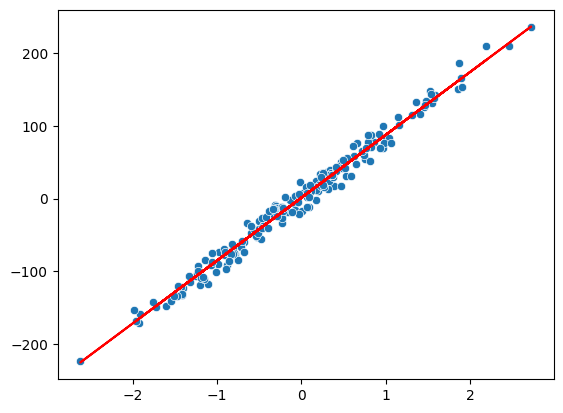

MSE OF R 121.53133062770917
MSE Ridge: 116.72574074735998


In [21]:
import numpy as np
import pandas as pd

# Simple Ridge Regression
class My_Ridge:
    def __init__(self, alpha=1):
        self.m = None
        self.b = None
        self.alpha = alpha

    def fit(self, X, y):
        X = X.flatten()
        
        num = np.sum((X - X.mean()) * (y - y.mean()))
        den = np.sum((X - X.mean())**2) + self.alpha

        self.m = num / den
        self.b = y.mean() - self.m * X.mean()

    def predict(self, X):
        return self.m * X.flatten() + self.b
from sklearn.datasets import make_regression

# Generate dataset
X, y = make_regression(
    n_samples=200,     # number of rows
    n_features=1,      # number of features
    noise=10,          # add noise
    random_state=42
)

print(X.shape, y.shape)

# Plot 
import seaborn as sns
sns.scatterplot(x=X.flatten(), y=y)


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
LR = LinearRegression()

LR.fit(X_train,y_train)
y_pred = LR.predict(X_test)
print("MSE",mean_squared_error(y_test,y_pred))

import matplotlib.pyplot as plt
plt.plot(X_test, y_pred, color='red')   # predicted line
plt.show()

# Now USe Ridge Regression 
R = My_Ridge()
R.fit(X_train,y_train)
y_pred_R = R.predict(X_test)

print("MSE OF R",mean_squared_error(y_test,y_pred_R))


from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)

y_pred_R1 = ridge.predict(X_test)

print("MSE Ridge:", mean_squared_error(y_test, y_pred_R1))

In [28]:
class Multiple_ridge:
    def __init__(self, alpha=0.1):
        self.m = None
        self.b = None
        self.alpha = alpha

    def fit(self, X, y):
        X = np.insert(X,0,1,axis=1)
        I = np.eye(X.shape[1])
        I[0, 0] = 0   # don't penalize bias

        beta = np.linalg.inv(X.T @ X + self.alpha * I) @ X.T @ y
        
        self.b = beta[0]
        self.m = beta[1:]
        

    def predict(self, X_test):
        y_pred = np.dot(X_test,self.m)+self.b
        return y_pred
# Load DAtaset
from sklearn.datasets import load_diabetes
X,y = load_diabetes(return_X_y=True)
from sklearn.model_selection import train_test_split

# Sk-learn Ridge class
from sklearn.linear_model import Ridge
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
R = Ridge(alpha = 0.1)
R.fit(X_train,y_train)
y_pred = R.predict(X_test)
print(mean_squared_error(y_test,y_pred))

# Our Ridge Class
R_1 = Multiple_ridge()
R_1.fit(X_train,y_train)
y_pred_mine = R_1.predict(X_test)
print("MSE Of My Class",mean_squared_error(y_test,y_pred_mine))

# linear_Regression 
from sklearn.linear_model import LinearRegression
l = LinearRegression()
l.fit(X_train,y_train)
y_pred_l = l.predict(X_test)
print("MSE Of LINEAR REGRESSION :",mean_squared_error(y_test,y_pred_l))

2856.486887670654
MSE Of My Class 2856.4868876706537
MSE Of LINEAR REGRESSION : 2900.1936284934795
